LinearRegression coefficients:
age     37.9040
sex   -241.9644
bmi    542.4288
bp     347.7038
s1    -931.4888
s2     518.0623
s3     163.4200
s4     275.3179
s5     736.1989
s6      48.6707

Model comparison:
            Model       MSE    RMSE     MAE     R2
Lasso (alpha=0.1) 2884.6243 53.7087 42.8052 0.4555
Ridge (alpha=1.0) 2892.0146 53.7775 42.8120 0.4541
 LinearRegression 2900.1936 53.8534 42.7941 0.4526


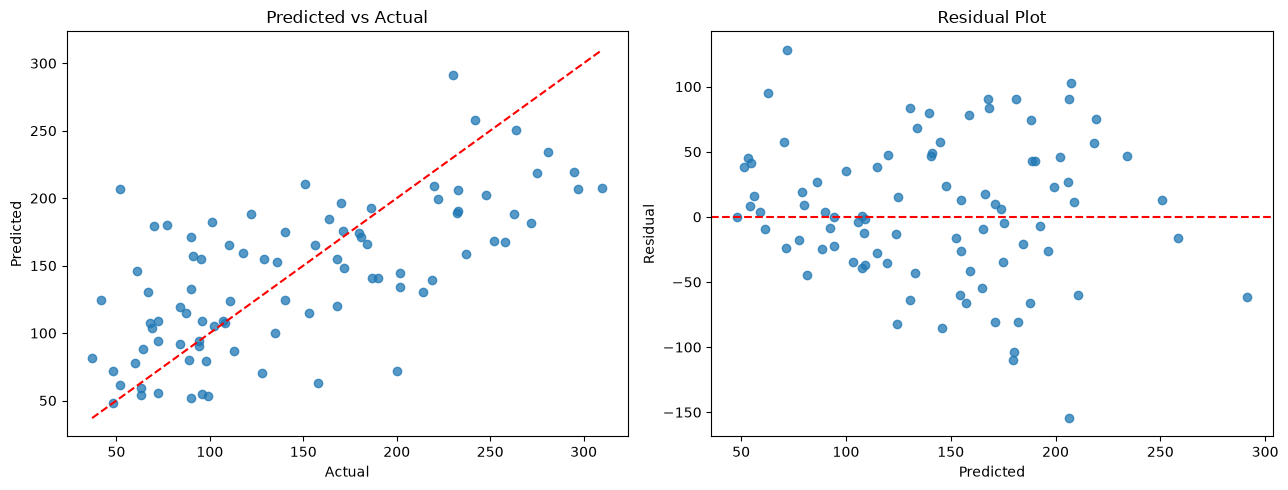

2026/09/21 10:26:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 10:26:17 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 10:26:20 INFO mlflow.tracking.fluent: Experiment with name 'w3d1-linear-regression' does not exist. Creating a new experiment.



Best model by RMSE: Lasso (alpha=0.1)


In [2]:
from pathlib import Path
import json
from typing import cast
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import Bunch

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / '.git').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'w3d1_linear_regression'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

data = cast(Bunch, load_diabetes(as_frame=True, return_X_y=False))
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1.0)': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (alpha=0.1)': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1, max_iter=10000))]),
}

metrics, predictions = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    predictions[name] = prediction
    mse = mean_squared_error(y_test, prediction)
    metrics.append({'Model': name, 'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(y_test, prediction), 'R2': r2_score(y_test, prediction)})

results = pd.DataFrame(metrics).sort_values('RMSE').reset_index(drop=True)
coefficients = pd.Series(models['LinearRegression'].coef_, index=X.columns, name='coefficient')
print('LinearRegression coefficients:')
print(coefficients.round(4).to_string())
print('\nModel comparison:')
print(results.round(4).to_string(index=False))

ols_prediction = predictions['LinearRegression']
residuals = y_test - ols_prediction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, ols_prediction, alpha=0.75)
limits = [min(y_test.min(), ols_prediction.min()), max(y_test.max(), ols_prediction.max())]
axes[0].plot(limits, limits, 'r--')
axes[0].set(title='Predicted vs Actual', xlabel='Actual', ylabel='Predicted')
axes[1].scatter(ols_prediction, residuals, alpha=0.75)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(title='Residual Plot', xlabel='Predicted', ylabel='Residual')
fig.tight_layout()
plot_path = OUTPUT_DIR / 'linear_regression_evaluation.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')

results_path = OUTPUT_DIR / 'model_comparison.csv'
coefficients_path = OUTPUT_DIR / 'linear_regression_coefficients.csv'
summary_path = OUTPUT_DIR / 'run_summary.json'
results.to_csv(results_path, index=False)
coefficients.rename_axis('feature').reset_index().to_csv(coefficients_path, index=False)
summary_path.write_text(json.dumps({'best_model_by_rmse': results.loc[0, 'Model'], 'random_state': RANDOM_STATE}, indent=2), encoding='utf-8')

mlflow.set_tracking_uri(f"sqlite:///{(OUTPUT_DIR / 'mlflow.db').resolve().as_posix()}")
mlflow.set_experiment('w3d1-linear-regression')
with mlflow.start_run(run_name='linear-regression-comparison'):
    mlflow.log_params({'dataset': 'diabetes', 'test_size': 0.20, 'random_state': RANDOM_STATE})
    for row in metrics:
        prefix = row['Model'].split()[0].lower()
        mlflow.log_metrics({f'{prefix}_{metric.lower()}': float(row[metric]) for metric in ['MSE', 'RMSE', 'MAE', 'R2']})
    mlflow.log_artifact(str(plot_path), artifact_path='evidence')
    mlflow.log_artifact(str(results_path), artifact_path='evidence')
    mlflow.log_artifact(str(coefficients_path), artifact_path='evidence')

print(f"\nBest model by RMSE: {results.loc[0, 'Model']}")
